# 03 — Mohr Circles and the Mohr–Coulomb Failure Criterion

**Short course:** *Geomorphological Hazards of Slopes* &nbsp;•&nbsp; University of Silesia in Katowice &nbsp;•&nbsp; 2 ECTS

*Lecturer: Ola Fredin*

---

The Mohr circle is the single most useful diagram in soil mechanics: it turns the abstract idea of *stress on a plane* into a picture you can read in seconds. Combined with the Mohr–Coulomb failure envelope, it tells you immediately whether a soil element is safe, at failure, or somewhere in between.


## About this notebook

**Learning objectives.** By the end of this notebook the student will be able to:

1. Construct a Mohr circle from the principal effective stresses $\sigma'_1$ and $\sigma'_3$.
2. Plot the Mohr–Coulomb failure envelope for given $c'$ and $\varphi'$.
3. Decide visually and numerically whether a stress state is stable, at incipient failure, or has failed.
4. Discuss how a rise in pore-water pressure shifts the circle and can trigger failure on a Carpathian flysch slope.

**Prerequisites.** Notebook `02 — Effective stress and pore-water pressure`. The lecture on *Soil mechanics and slope stability*.

> **For your PowerPoint deck.** The two key figures — the labelled Mohr circle with envelope (`mohr_circle_with_envelope.svg`) and the pore-pressure-shift diagram (`pore_pressure_shift.svg`) — are saved to `figures/`. Drop the SVGs straight into PowerPoint. Equation cells (1) – (5) below are the ones I screenshot for the slides.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from style import apply_style, COLORS, save_figure
apply_style()

from ipywidgets import interact, FloatSlider


## 1. Stress on a plane — the Mohr circle

Consider a 2-D soil element loaded by principal **effective** stresses $\sigma'_1 \geq \sigma'_3$ (compression positive). On a plane whose normal makes an angle $\theta$ with the direction of $\sigma'_1$, the normal and shear stresses are

$$
\sigma'_n = \frac{\sigma'_1 + \sigma'_3}{2} + \frac{\sigma'_1 - \sigma'_3}{2}\cos 2\theta
\qquad (1)
$$

$$
\tau = \frac{\sigma'_1 - \sigma'_3}{2}\sin 2\theta
\qquad (2)
$$

As $\theta$ varies from $0$ to $\pi$, the point $(\sigma'_n, \tau)$ traces a **circle** in stress space with

$$
\text{centre} = \left(\tfrac{\sigma'_1 + \sigma'_3}{2},\; 0\right),
\qquad
\text{radius} = \tfrac{\sigma'_1 - \sigma'_3}{2}.
\qquad (3)
$$

That circle is the Mohr circle. Every plane through the soil element corresponds to exactly one point on it.

The pair of panels below makes this concrete. Panel (a) shows a 2-D soil element loaded by $\sigma'_1$ (vertical, larger) and $\sigma'_3$ (horizontal, smaller), with an inclined plane drawn through its centre at angle $\theta$. Resolved on that plane are the normal stress $\sigma'_n$ (orange, perpendicular to the plane) and the shear stress $\tau$ (red, along it). Panel (b) is the corresponding Mohr circle: the *same* plane shows up as a single point at angle $2\theta$ measured from the $\sigma'_1$ side, whose horizontal coordinate is $\sigma'_n$ and vertical coordinate is $\tau$. Every plane through the element is one such point; sweeping $\theta$ from $0$ to $\pi$ sweeps the point all the way around the circle.

In [ ]:
# Soil-element + Mohr-circle-point illustration.
# Left panel: a 2-D soil element with principal effective stresses
#             sigma_1 (vertical) and sigma_3 (horizontal), and an inclined
#             plane at angle theta with the resolved sigma_n and tau on it.
# Right panel: the same plane appears as a single point at 2*theta on the
#              Mohr circle, with projections onto the sigma_n and tau axes.
# Output: figures/mohr_element_and_circle.{svg,png}
from matplotlib.patches import Arc

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 5.8))

theta_deg = 35.0
theta = np.radians(theta_deg)
sigma1, sigma3 = 120.0, 30.0  # kPa, illustrative

# ==============================================================
# (a) LEFT PANEL — physical soil element
# ==============================================================
ax = axL
EX, EY = 6.0, 6.0
ELX0, ELY0 = 1.0, 1.0
SOIL_FILL = "#E8C9A4"
SOIL_EDGE = "#5C3317"
ax.add_patch(plt.Rectangle((ELX0, ELY0), EX, EY,
                           facecolor=SOIL_FILL, edgecolor=SOIL_EDGE,
                           linewidth=1.6, zorder=2))
cx, cy = ELX0 + EX/2, ELY0 + EY/2

# sigma_1 arrows (vertical, large)
arr_len = 1.4
for x_off in [-1.7, 0.0, 1.7]:
    x = cx + x_off
    ax.annotate("", xy=(x, ELY0 + EY + 0.04),
                xytext=(x, ELY0 + EY + arr_len),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=2.6, mutation_scale=22), zorder=4)
    ax.annotate("", xy=(x, ELY0 - 0.04),
                xytext=(x, ELY0 - arr_len),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=2.6, mutation_scale=22), zorder=4)
ax.text(cx, ELY0 + EY + arr_len + 0.45, r"$\sigma'_1$",
        ha="center", va="bottom", fontsize=18, fontweight="bold")
ax.text(cx, ELY0 - arr_len - 0.45, r"$\sigma'_1$",
        ha="center", va="top", fontsize=18, fontweight="bold")

# sigma_3 arrows (horizontal, smaller)
arr_len_3 = 1.0
for y_off in [-1.7, 0.0, 1.7]:
    y = cy + y_off
    ax.annotate("", xy=(ELX0 + EX + 0.04, y),
                xytext=(ELX0 + EX + arr_len_3, y),
                arrowprops=dict(arrowstyle="-|>", color="dimgray",
                                lw=2.0, mutation_scale=18), zorder=4)
    ax.annotate("", xy=(ELX0 - 0.04, y),
                xytext=(ELX0 - arr_len_3, y),
                arrowprops=dict(arrowstyle="-|>", color="dimgray",
                                lw=2.0, mutation_scale=18), zorder=4)
ax.text(ELX0 + EX + arr_len_3 + 0.35, cy, r"$\sigma'_3$",
        ha="left", va="center", fontsize=16, color="dimgray", fontweight="bold")
ax.text(ELX0 - arr_len_3 - 0.35, cy, r"$\sigma'_3$",
        ha="right", va="center", fontsize=16, color="dimgray", fontweight="bold")

# Inclined plane through the element centre
tx, ty = np.cos(theta), np.sin(theta)
nx, ny = -np.sin(theta), np.cos(theta)
ts = np.linspace(-6.0, 6.0, 400)
xs = cx + ts * tx
ys = cy + ts * ty
mask = (xs >= ELX0) & (xs <= ELX0 + EX) & (ys >= ELY0) & (ys <= ELY0 + EY)
ax.plot(xs[mask], ys[mask], color=COLORS["rock"],
        linestyle="--", linewidth=2.2, zorder=3)

# sigma_n arrow (normal to plane)
arrow_norm_len = 1.7
ax.annotate("",
            xy=(cx + nx * arrow_norm_len, cy + ny * arrow_norm_len),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle="-|>", color=COLORS["accent"],
                            lw=2.6, mutation_scale=22), zorder=5)
ax.text(cx + nx * (arrow_norm_len + 0.45),
        cy + ny * (arrow_norm_len + 0.45),
        r"$\sigma'_n$",
        fontsize=17, color=COLORS["accent"], fontweight="bold",
        ha="center", va="center", zorder=6)

# tau arrow (along the plane)
tau_len = 1.7
ax.annotate("",
            xy=(cx + tx * tau_len, cy + ty * tau_len),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle="-|>", color=COLORS["fail"],
                            lw=2.6, mutation_scale=22), zorder=5)
ax.text(cx + tx * (tau_len + 0.45),
        cy + ty * (tau_len + 0.45),
        r"$\tau$",
        fontsize=17, color=COLORS["fail"], fontweight="bold",
        ha="center", va="center", zorder=6)

# Angle theta between the inclined plane and the horizontal
t_b = (cy - ELY0) / ty
px = cx - tx * t_b
py = ELY0
if not (ELX0 <= px <= ELX0 + EX):
    t_l = (cx - ELX0) / tx
    px, py = ELX0, cy - ty * t_l
ax.add_patch(Arc((px, py), 2.0, 2.0, angle=0,
                 theta1=0, theta2=theta_deg, color="dimgray", lw=1.6))
mid_ang = np.radians(theta_deg / 2)
ax.text(px + 1.3 * np.cos(mid_ang), py + 1.3 * np.sin(mid_ang),
        r"$\theta$", fontsize=17, color="dimgray", fontweight="bold")

ax.set_xlim(-1.5, 11.5)
ax.set_ylim(-1.5, 10.0)
ax.set_aspect("equal")
ax.grid(False); ax.axis("off")
ax.set_title("(a)  Physical element: plane at angle $\\theta$",
             pad=10, fontsize=14)

# ==============================================================
# (b) RIGHT PANEL — Mohr circle, with the point that maps to the plane above
# ==============================================================
ax = axR
p_centre = 0.5 * (sigma1 + sigma3)
q_radius = 0.5 * (sigma1 - sigma3)
two_theta = 2 * theta_deg
sn_pt = p_centre + q_radius * np.cos(np.radians(two_theta))
tau_pt = q_radius * np.sin(np.radians(two_theta))

# Full circle (light grey) + upper half (accent)
thetas = np.linspace(0, 2*np.pi, 300)
ax.plot(p_centre + q_radius*np.cos(thetas),
        q_radius*np.sin(thetas),
        color="lightgrey", lw=2.0, zorder=2)
thetas_up = np.linspace(0, np.pi, 200)
ax.plot(p_centre + q_radius*np.cos(thetas_up),
        q_radius*np.sin(thetas_up),
        color=COLORS["accent"], lw=2.4, zorder=3, label="Mohr circle")

ax.axhline(0, color="black", lw=0.8)

# Principal-stress markers + labels
ax.plot([sigma1, sigma3], [0, 0], "o", color=COLORS["rock"],
        markersize=8, zorder=4)
ax.annotate(r"$\sigma'_1$", (sigma1, 0), xytext=(8, 6),
            textcoords="offset points", fontsize=15, fontweight="bold")
ax.annotate(r"$\sigma'_3$", (sigma3, 0), xytext=(8, 6),
            textcoords="offset points", fontsize=15, fontweight="bold")
ax.plot(p_centre, 0, "x", color="black", markersize=8, zorder=4)

# Highlighted point (corresponds to the inclined plane in panel a)
ax.plot(sn_pt, tau_pt, "o", color=COLORS["fail"], markersize=14, zorder=6,
        markeredgecolor="black", markeredgewidth=1.2)
ax.plot([sn_pt, sn_pt], [0, tau_pt], "--", color="grey", lw=1.0, zorder=2)
ax.plot([0, sn_pt], [tau_pt, tau_pt], "--", color="grey", lw=1.0, zorder=2)

ax.text(sn_pt, -8, r"$\sigma'_n$", ha="center", va="top",
        fontsize=15, color=COLORS["accent"], fontweight="bold")
ax.text(-6, tau_pt, r"$\tau$", ha="right", va="center",
        fontsize=15, color=COLORS["fail"], fontweight="bold")

# Angle 2*theta arc at the circle centre
arc_r = 0.45 * q_radius
ax.add_patch(Arc((p_centre, 0), 2*arc_r, 2*arc_r,
                 angle=0, theta1=0, theta2=two_theta,
                 color=COLORS["accent"], lw=1.8))
mid_ang_circ = np.radians(two_theta / 2)
ax.text(p_centre + (arc_r + 4) * np.cos(mid_ang_circ),
        (arc_r + 4) * np.sin(mid_ang_circ),
        r"$2\theta$", fontsize=15,
        color=COLORS["accent"], fontweight="bold")

# Radius line from centre to highlighted point
ax.plot([p_centre, sn_pt], [0, tau_pt],
        color=COLORS["accent"], lw=1.2, alpha=0.7, zorder=2)

ax.set_xlabel(r"effective normal stress  $\sigma'_n$  [kPa]")
ax.set_ylabel(r"shear stress  $\tau$  [kPa]")
ax.set_title("(b)  Mohr circle: the same plane is one point at $2\\theta$",
             pad=10, fontsize=14)
ax.set_xlim(-15, 145)
ax.set_ylim(-30, 75)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

save_figure(fig, "mohr_element_and_circle")
plt.show()


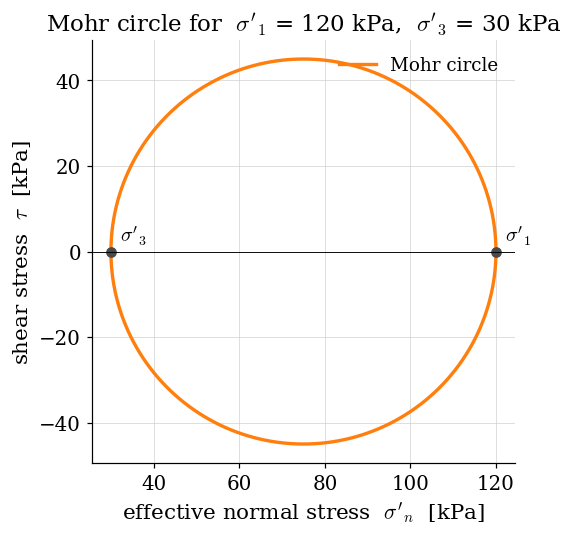

Centre p = 75.0 kPa,  radius q = 45.0 kPa


In [ ]:
def mohr_circle_points(sigma1, sigma3, n=200):
    """Return arrays of (sigma_n, tau) tracing the Mohr circle."""
    p = 0.5 * (sigma1 + sigma3)         # centre
    q = 0.5 * (sigma1 - sigma3)         # radius
    theta = np.linspace(0.0, np.pi, n)
    sigma_n = p + q * np.cos(2 * theta)
    tau = q * np.sin(2 * theta)
    return sigma_n, tau, p, q


# A first illustrative state: dense sand with moderate confinement.
sigma1, sigma3 = 120.0, 30.0  # kPa
sn, tau, p, q = mohr_circle_points(sigma1, sigma3)

fig, ax = plt.subplots()
ax.plot(sn, tau, color=COLORS["accent"], lw=2.2, label="Mohr circle")
ax.plot([sigma1, sigma3], [0, 0], "o", color=COLORS["rock"])
ax.annotate(r"$\sigma'_1$", (sigma1, 0), xytext=(6, 6), textcoords="offset points")
ax.annotate(r"$\sigma'_3$", (sigma3, 0), xytext=(6, 6), textcoords="offset points")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel(r"effective normal stress  $\sigma'_n$  [kPa]")
ax.set_ylabel(r"shear stress  $\tau$  [kPa]")
ax.set_title(f"Mohr circle for  $\\sigma'_1$ = {sigma1:.0f} kPa,  $\\sigma'_3$ = {sigma3:.0f} kPa")
ax.set_aspect("equal")
ax.legend(loc="upper right")

save_figure(fig, "mohr_circle_basic")
plt.show()

print(f"Centre p = {p:.1f} kPa,  radius q = {q:.1f} kPa")


## 2. The Mohr–Coulomb failure envelope

A soil element fails along a plane when, on that plane, the shear stress reaches the available shear strength. For drained conditions this is the **Mohr–Coulomb criterion**:

$$
\boxed{\;\tau_f \;=\; c' \;+\; \sigma'_n \,\tan\varphi' \;}
\qquad (4)
$$

with effective cohesion $c'$ and effective friction angle $\varphi'$. The locus of $(\sigma'_n, \tau_f)$ is a straight line — the **failure envelope**.

A stress state is **safe** as long as its Mohr circle stays entirely below the envelope. **Failure** is reached when the circle is tangent to the envelope. The point of tangency is the **failure plane**.

Geometrically, the perpendicular distance from the circle centre $(p, 0)$ to the envelope is $c'\cos\varphi' + p\sin\varphi'$. Failure means this distance equals the radius $q$:

$$
q \;=\; c'\cos\varphi' + p\sin\varphi'
\qquad (5)
$$

A convenient stress-space factor of safety is then

$$
\mathrm{FS} \;=\; \frac{c'\cos\varphi' + p\sin\varphi'}{q}.
\qquad (6)
$$

$\mathrm{FS} > 1$ is safe, $\mathrm{FS} = 1$ is at failure, $\mathrm{FS} < 1$ means the assumed stress state is not physically attainable — the soil would have failed first.


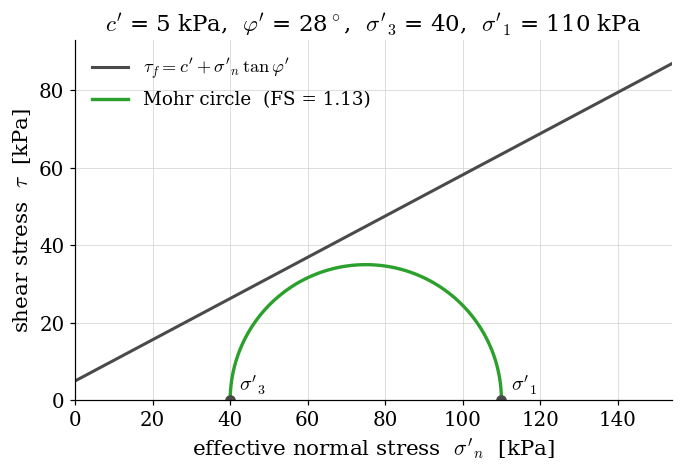

Factor of safety in this stress state:  FS = 1.13


In [ ]:
def envelope(sigma_n, c_prime, phi_deg):
    """Mohr-Coulomb failure envelope tau_f(sigma_n)."""
    return c_prime + sigma_n * np.tan(np.radians(phi_deg))


def factor_of_safety(sigma1, sigma3, c_prime, phi_deg):
    """Stress-space FS = (perpendicular distance from centre to envelope) / radius."""
    phi = np.radians(phi_deg)
    p = 0.5 * (sigma1 + sigma3)
    q = 0.5 * (sigma1 - sigma3)
    return (c_prime * np.cos(phi) + p * np.sin(phi)) / q


def plot_mohr_with_envelope(sigma1, sigma3, c_prime, phi_deg, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    sn, tau, p, q = mohr_circle_points(sigma1, sigma3)
    FS = factor_of_safety(sigma1, sigma3, c_prime, phi_deg)
    circle_color = COLORS["safe"] if FS > 1.0 else COLORS["fail"]

    # envelope
    sn_axis = np.linspace(0, max(sigma1 * 1.4, 1.0), 200)
    ax.plot(sn_axis, envelope(sn_axis, c_prime, phi_deg),
            color=COLORS["rock"], lw=2.0,
            label=fr"$\tau_f = c' + \sigma'_n\,\tan\varphi'$")

    # circle
    ax.plot(sn, tau, color=circle_color, lw=2.2,
            label=fr"Mohr circle  (FS = {FS:.2f})")

    # markers
    ax.plot([sigma1, sigma3], [0, 0], "o", color=COLORS["rock"])
    ax.annotate(r"$\sigma'_1$", (sigma1, 0), xytext=(6, 6), textcoords="offset points")
    ax.annotate(r"$\sigma'_3$", (sigma3, 0), xytext=(6, 6), textcoords="offset points")
    ax.axhline(0, color="black", lw=0.6)

    ax.set_xlabel(r"effective normal stress  $\sigma'_n$  [kPa]")
    ax.set_ylabel(r"shear stress  $\tau$  [kPa]")
    if title is None:
        title = (fr"$c'$ = {c_prime:.0f} kPa,  "
                 fr"$\varphi'$ = {phi_deg:.0f}$^\circ$,  "
                 fr"$\sigma'_3$ = {sigma3:.0f},  $\sigma'_1$ = {sigma1:.0f} kPa")
    ax.set_title(title)
    ax.set_xlim(0, max(sigma1 * 1.4, 1.0))
    ax.set_ylim(bottom=0)
    ax.set_aspect("equal")
    ax.legend(loc="upper left")
    return fig, ax, FS


# A representative Carpathian flysch, silty sand: low cohesion, moderate friction.
# Stress state is marginally stable (FS just above 1.0) -- a realistic pre-trigger condition.
fig, ax, FS = plot_mohr_with_envelope(sigma1=110.0, sigma3=40.0,
                                      c_prime=5.0, phi_deg=28.0)
save_figure(fig, "mohr_circle_with_envelope")
plt.show()
print(f"Factor of safety in this stress state:  FS = {FS:.2f}")


## 3. Interactive Mohr circle

Slide the four parameters and watch the circle move relative to the envelope. Three things are worth pausing on:

- **Increase $\sigma'_3$** (lateral confinement). The circle shifts right *and* shrinks — sand at depth is harder to fail.
- **Drop $c'$ to 0**. The envelope passes through the origin; this is a clean **granular** soil. Any tensile stress would be physically impossible.
- **Reduce $\varphi'$**. The envelope flattens — typical of a weak clay or a residual surface.


In [ ]:
def explore(sigma1=120.0, sigma3=30.0, c_prime=5.0, phi_deg=28.0):
    fig, ax = plt.subplots()
    plot_mohr_with_envelope(sigma1, sigma3, c_prime, phi_deg, ax=ax)
    plt.show()


interact(
    explore,
    sigma1=FloatSlider(min=10, max=300, step=5, value=120.0, description=r"$\sigma'_1$ [kPa]"),
    sigma3=FloatSlider(min=0,  max=200, step=5, value=30.0,  description=r"$\sigma'_3$ [kPa]"),
    c_prime=FloatSlider(min=0, max=50,  step=1, value=5.0,   description=r"$c'$ [kPa]"),
    phi_deg=FloatSlider(min=10, max=45, step=1, value=28.0,  description=r"$\varphi'$ [deg]"),
);


interactive(children=(FloatSlider(value=120.0, description="$\\sigma'_1$ [kPa]", max=300.0, min=10.0, step=5.0…

## 4. Worked example: pore-pressure rise on a Carpathian flysch slope

A shallow translational slide is being considered on a Carpathian flysch slope. A soil element at the potential slip surface has the following **total** stress state, estimated from overburden and slope geometry:

|             | value     |
|-------------|-----------|
| $\sigma_1$  | 140 kPa   |
| $\sigma_3$  | 70 kPa    |
| $c'$        | 5 kPa     |
| $\varphi'$  | 28°       |

Before a rainstorm the pore-water pressure at the slip surface is $u_0 = 30$ kPa — the slope is **marginally stable** (FS just above one). After three days of heavy rain the pressure has risen to $u_1 = 60$ kPa as a perched water table reaches the slip surface.

We translate to **effective** stresses by $\sigma' = \sigma - u$ — the Mohr circle simply shifts to the left along the $\sigma_n$ axis without changing size — and see what the envelope says.


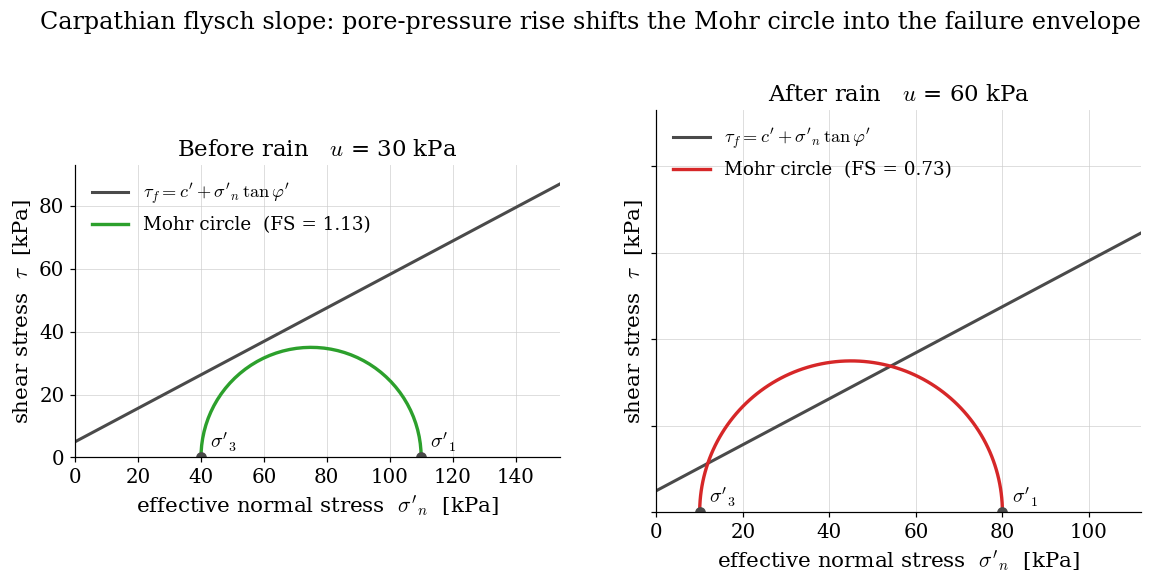

Before rain:  FS = 1.13
After rain:   FS = 0.73
As mentioned, safetyfactor (FS) above 1.0 indicates a stable slope, while FS below 1.0 indicates failure.


In [ ]:
sigma1_tot, sigma3_tot = 140.0, 70.0
c_prime, phi_deg = 5.0, 28.0

u0, u1 = 30.0, 60.0   # pore-water pressure, before and after rain
sigma1_pre,  sigma3_pre  = sigma1_tot - u0, sigma3_tot - u0
sigma1_post, sigma3_post = sigma1_tot - u1, sigma3_tot - u1

FS_pre  = factor_of_safety(sigma1_pre,  sigma3_pre,  c_prime, phi_deg)
FS_post = factor_of_safety(sigma1_post, sigma3_post, c_prime, phi_deg)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)
plot_mohr_with_envelope(sigma1_pre,  sigma3_pre,  c_prime, phi_deg,
                        ax=axes[0],
                        title=fr"Before rain   $u$ = {u0:.0f} kPa")
plot_mohr_with_envelope(sigma1_post, sigma3_post, c_prime, phi_deg,
                        ax=axes[1],
                        title=fr"After rain   $u$ = {u1:.0f} kPa")
fig.suptitle("Carpathian flysch slope: pore-pressure rise shifts the Mohr circle into the failure envelope",
             y=1.02)
save_figure(fig, "pore_pressure_shift")
plt.show()

print(f"Before rain:  FS = {FS_pre:.2f}")
print(f"After rain:   FS = {FS_post:.2f}")
print("As mentioned, safetyfactor (FS) above 1.0 indicates a stable slope, while FS below 1.0 indicates failure.")


**Interpretation.** Total stresses are unchanged — no new load has been added to the slope. What rainfall did was raise the pore pressure, which pushed the Mohr circle to the left until it crossed the envelope. The mechanical condition for failure was met without anything visibly happening on the slope. This is exactly why so many shallow Central-European slides initiate during or just after multi-day rainstorms (cf. Tichavský et al., 2019).

It is also why **drainage** is one of the most cost-effective slope-stabilisation measures: it caps $u$, holding the circle to the right of the envelope.


## Take-aways

- The Mohr circle is just a graphical re-statement of the 2-D stress transformation; its centre is the mean effective stress, its radius is the deviatoric stress.
- The Mohr–Coulomb criterion turns *strength* into a single straight line on the same axes — the circle either touches it (failure) or not (safe).
- Pore-water pressure shifts the circle without changing its size. Rainfall-triggered slope failures are, mechanically, a left-shift of the circle into the envelope.
- The stress-space factor of safety in equation (6) is a quick way to compare "before / after" scenarios for triggering, drainage, or loading.


## Voluntary excercises

1. A soil element has $\sigma'_1 = 200$ kPa and $\sigma'_3 = 50$ kPa. For $c' = 0$ and $\varphi' = 32^\circ$, compute the factor of safety using equation (6). Is the element safe?
2. Sketch how the Mohr circle moves if (a) $\sigma_1$ doubles at constant $\sigma_3$ and constant $u$; (b) $u$ rises by 30 kPa at constant total stresses. Mark whether each move brings the element closer to or further from failure.
3. Two Carpathian sites have similar slope geometry but different soils: site A has $c' = 10$ kPa, $\varphi' = 25^\circ$; site B has $c' = 0$, $\varphi' = 35^\circ$. Which is more sensitive to a rainfall-driven rise in pore pressure? Justify in one or two sentences.
4. Why is drainage usually a more effective stabilisation measure than adding surface weight ("counter-berm") on a marginally stable flysch slope? Frame your answer in terms of where the Mohr circle moves.

## References

- Hungr, O., Leroueil, S., & Picarelli, L. (2014). *The Varnes classification of landslide types, an update.* Landslides, 11(2), 167–194. https://doi.org/10.1007/s10346-013-0436-y
- Tichavský, R., Ballesteros-Cánovas, J. A., Šilhán, K., Tolasz, R., & Stoffel, M. (2019). *Dry spells and extreme precipitation are the main trigger of landslides in Central Europe.* Scientific Reports, 9, 14560. https://doi.org/10.1038/s41598-019-51148-2
- Iverson, R. M. (2000). *Landslide triggering by rain infiltration.* Water Resources Research, 36(7), 1897–1910.
